## Current workflow review copy

Synchronized with the completed 18 September 2026 uncalibrated engine run. Upstream construction/household methods are retained; notebooks 05 onward use outputs/current. Notebooks 03–04 have no saved demonstration outputs in the current source. Read [the workflow](../../docs/ENGINE_WORKFLOW.md) and [interpretation](../../docs/INTERPRETATION.md). Packaging does not rerun calculations. Raw data, address-level outputs and interactive payloads are excluded.


In [ ]:
# Review copy: read saved results without running the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("Review copy: source inputs and third-party engines are excluded. Read saved results or use the Streamlit app.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


# 09 · Demand maps and annual/hourly results

All maps cover the borough stock. Total delivered energy is gas + electricity + other fuels, with no addition of useful heat. Building energy is summed across member dwellings; heat intensity is area weighted. The new hourly electricity curve is reconciled to the annual account but is not validated against hourly measurements.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown
from ukubem import unified as U, reporting as R
OUT = U.OUT
R.atlas()

LOCAL_PATH/core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


Annual LSOA sums; useful heat and delivered energy are different boundaries.

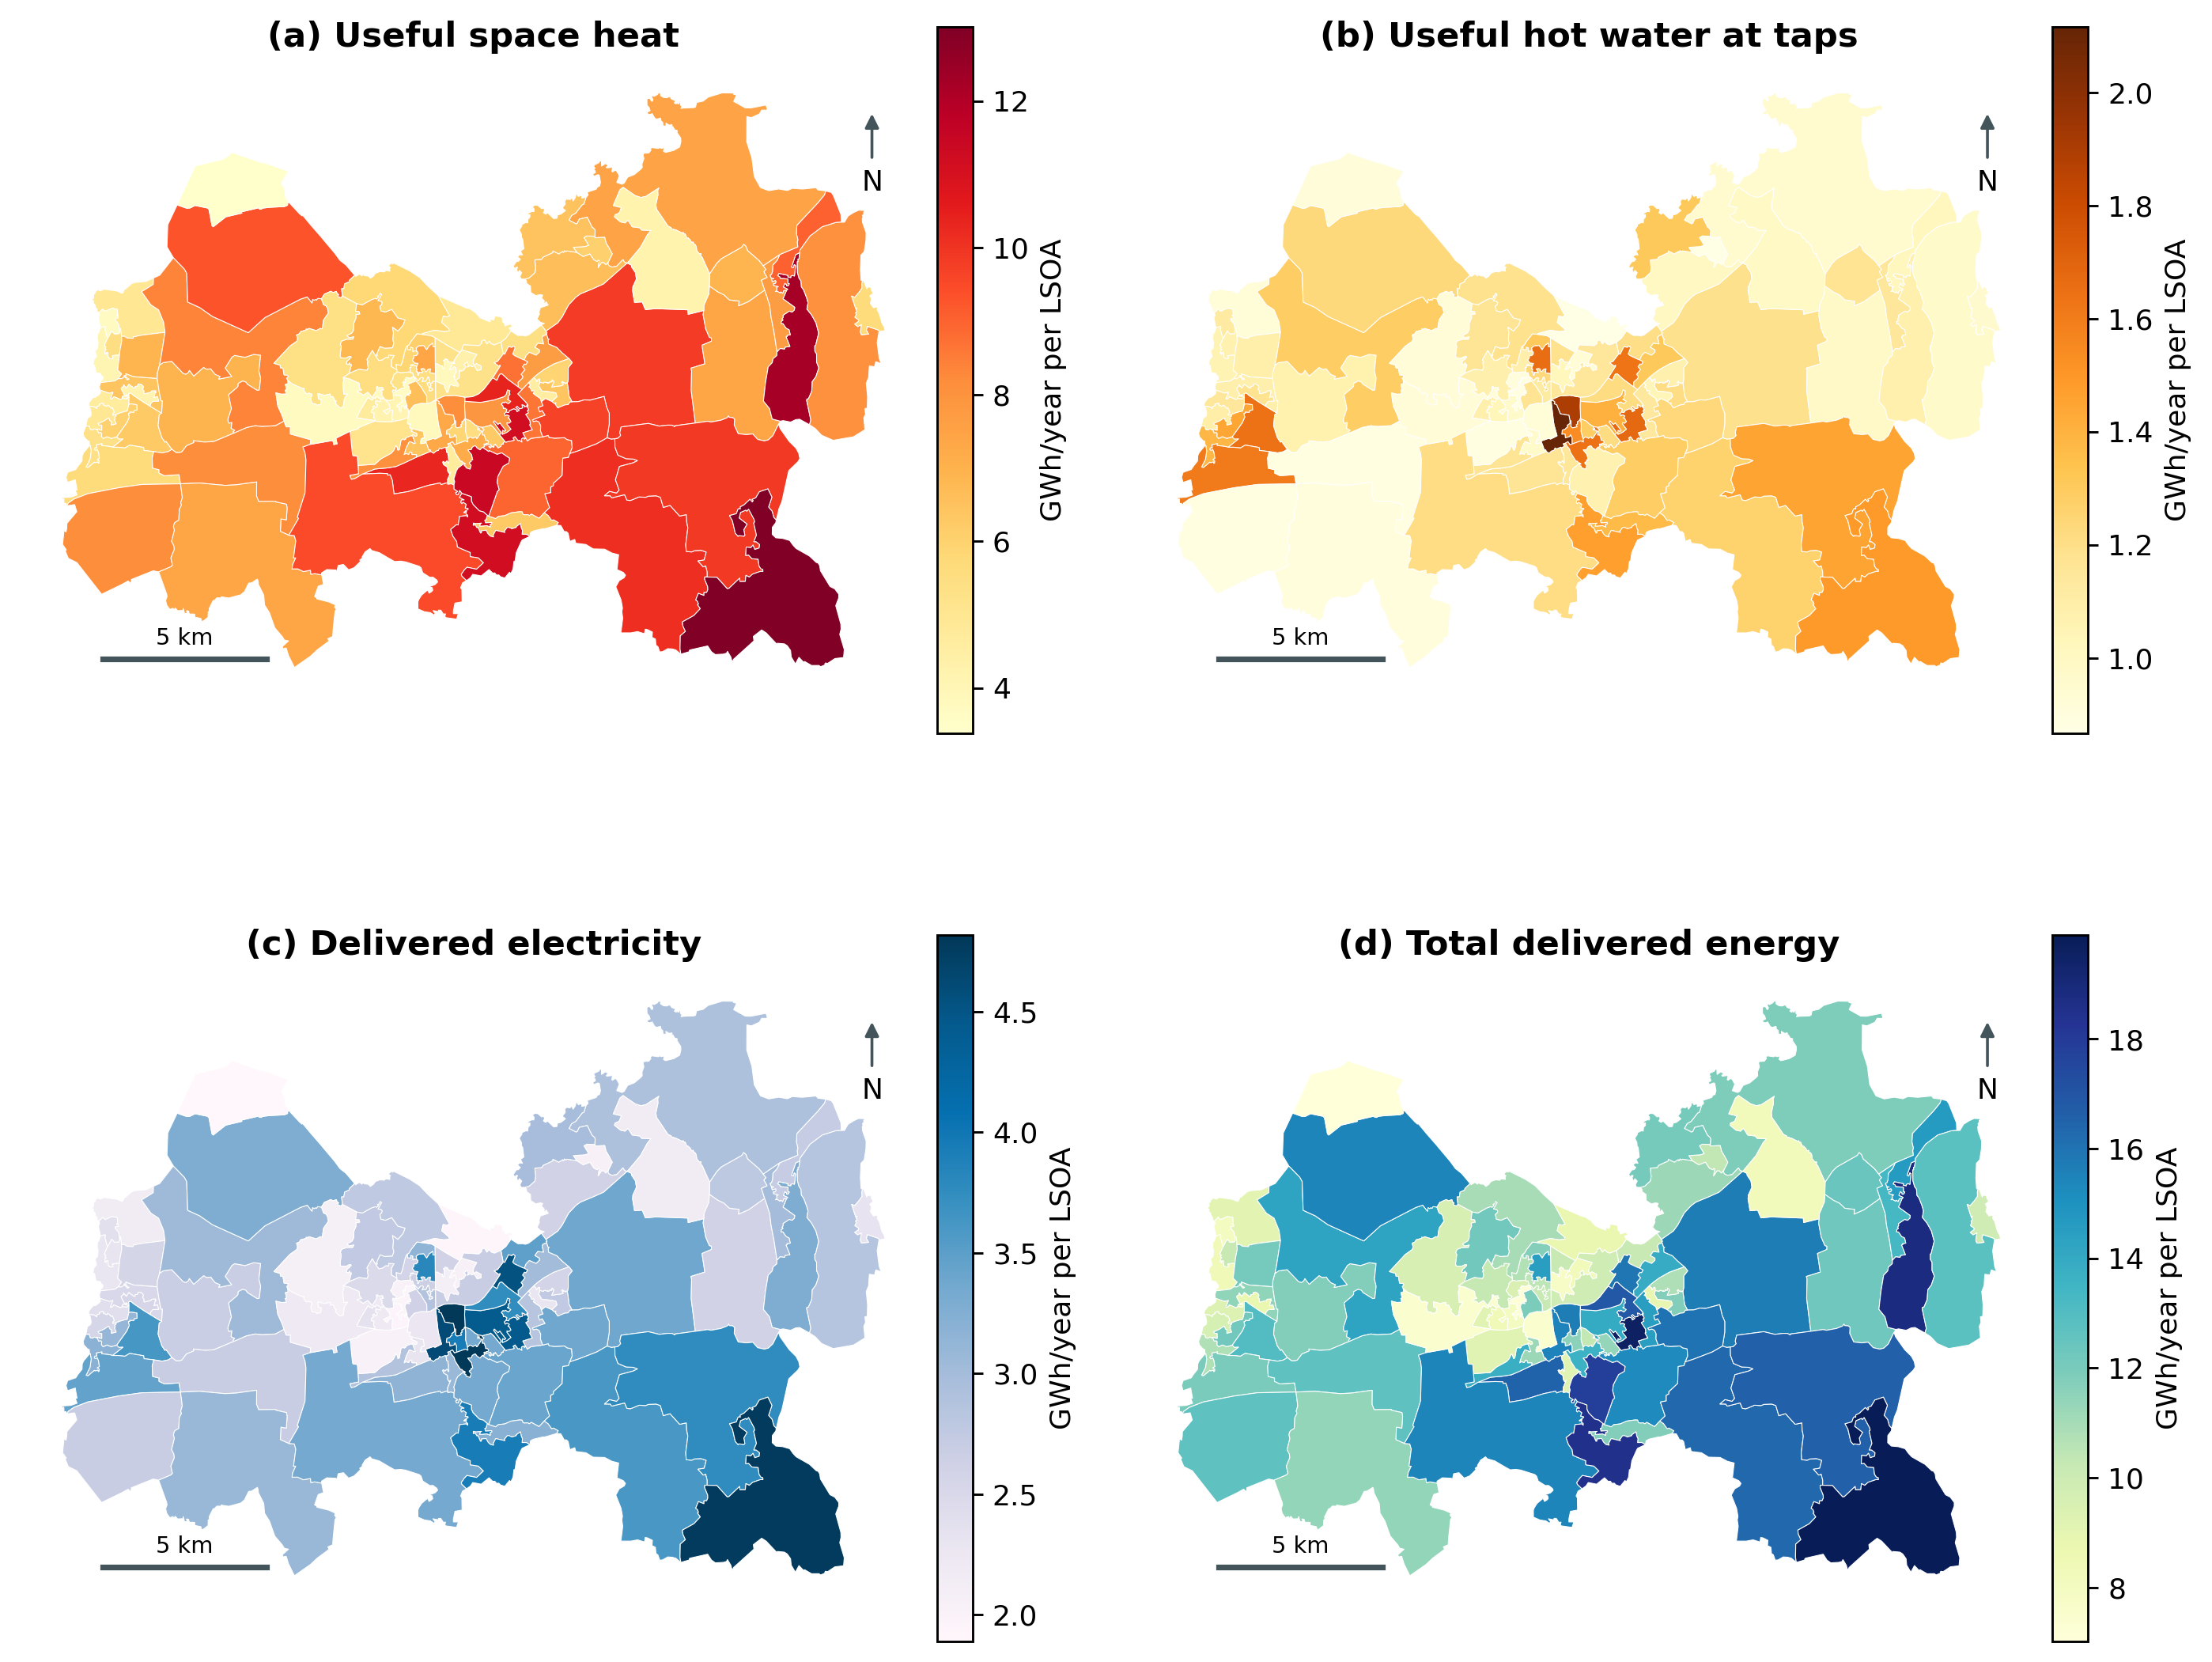

In [2]:
display(Image(filename=str(OUT/'figures/09_demand_totals_maps.png')))

All residential values are retained. Building-map colour scales are capped at the 98th percentile for readability; grey footprints lack modelled residential demand.

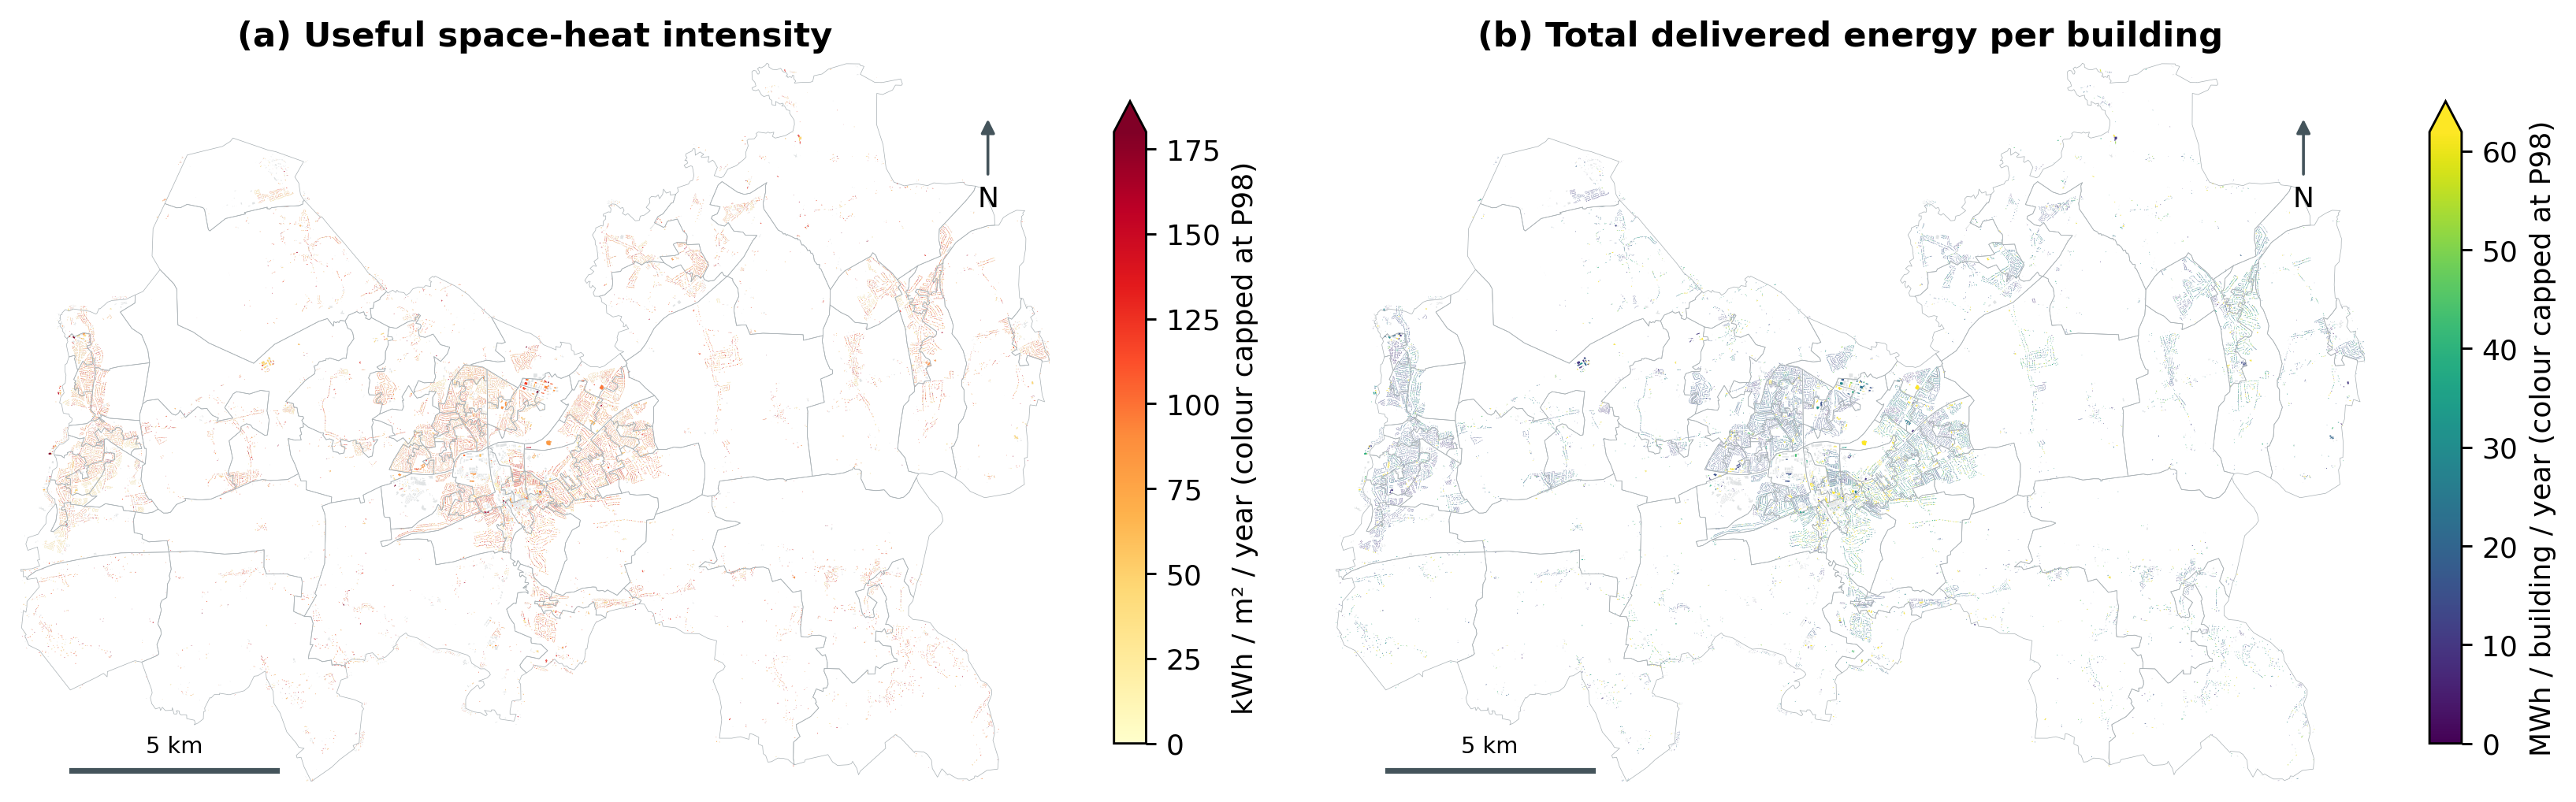

In [3]:
display(Image(filename=str(OUT/'figures/09_building_demand_maps.png')))

Annual targets are distributed across normalized hourly shapes. Peaks use simultaneous loads, not the sum of dwelling maxima.

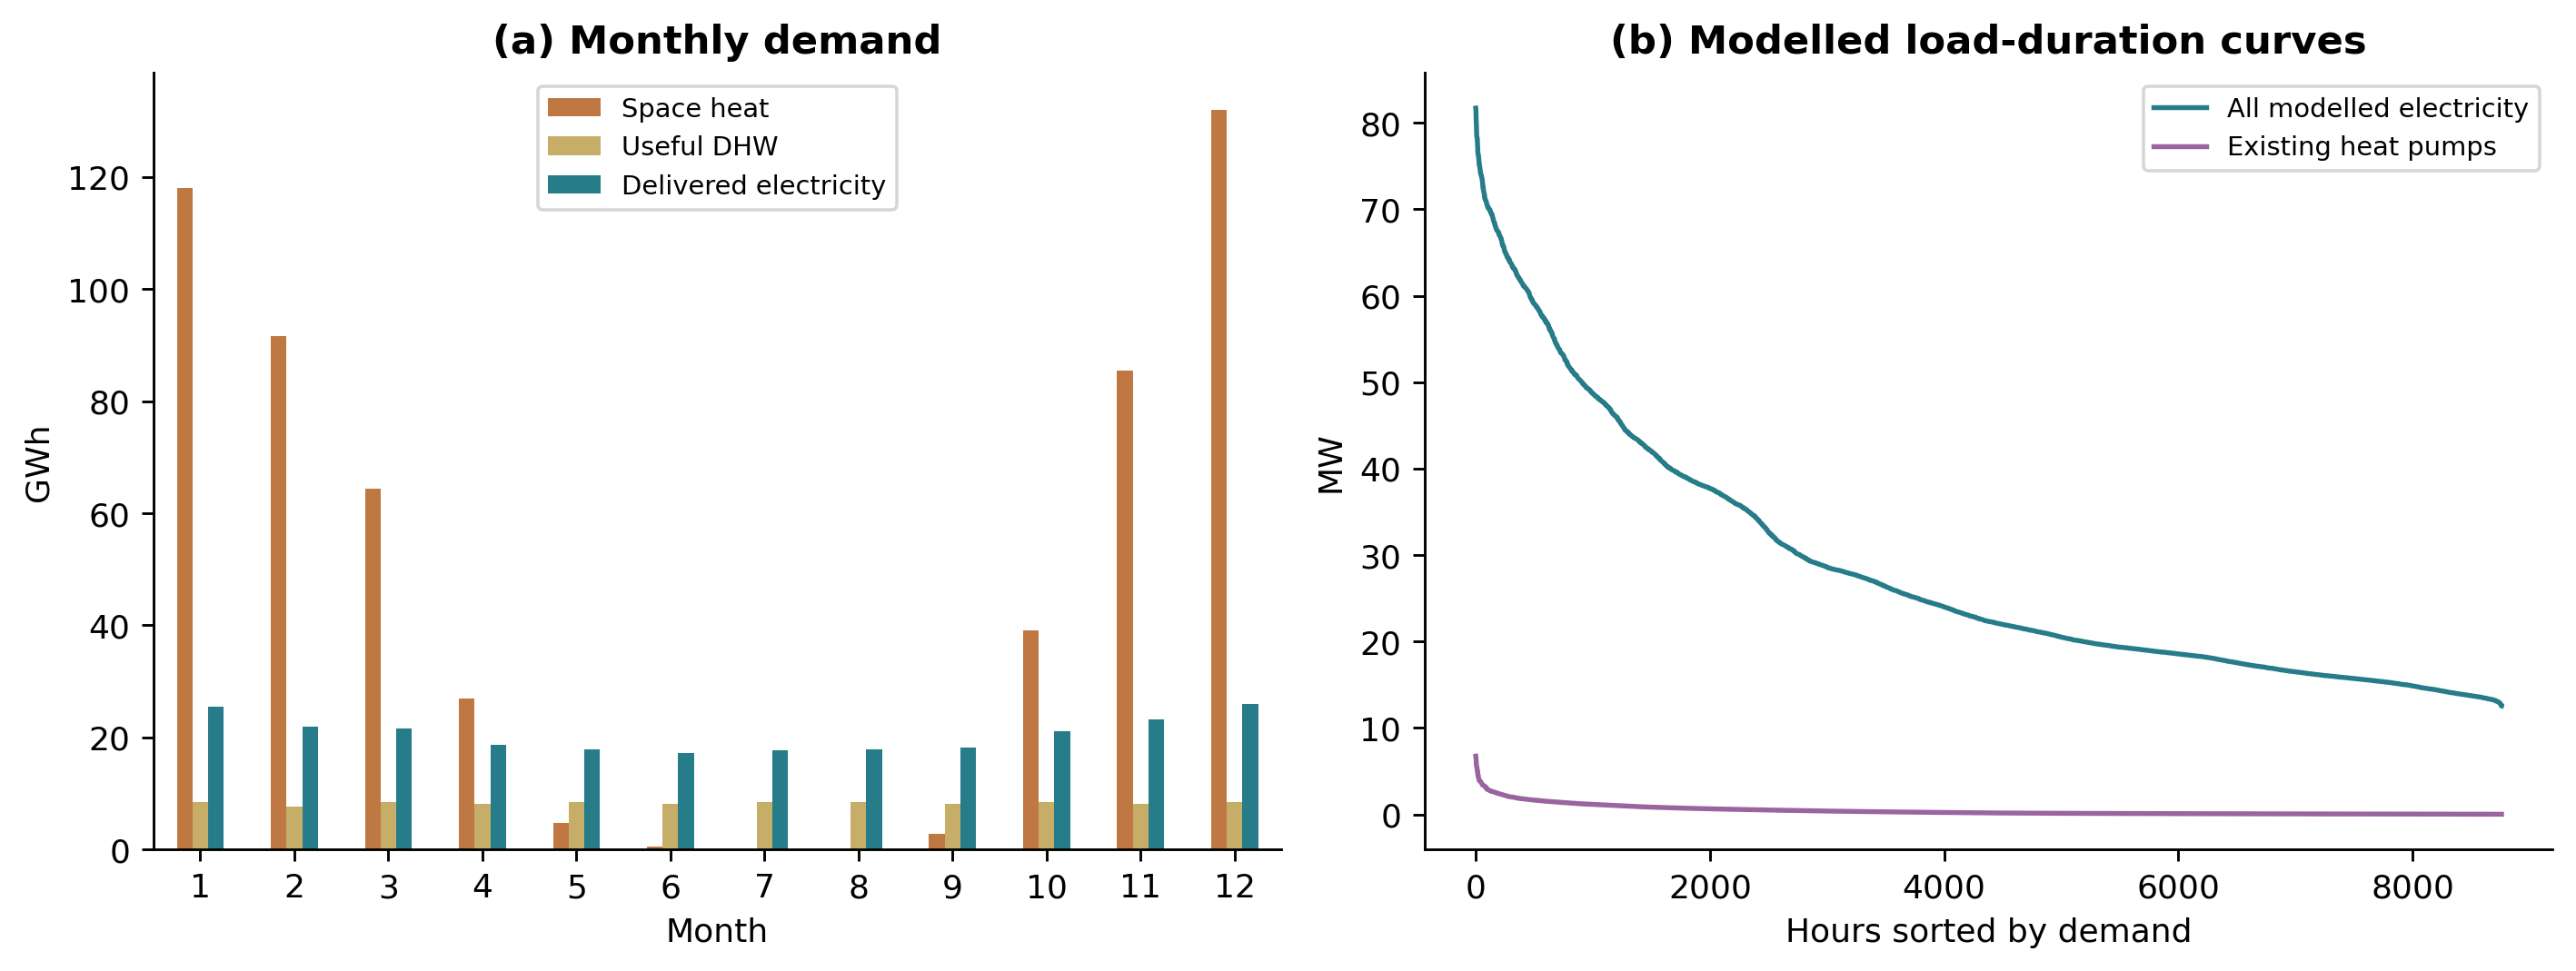

In [4]:
display(Image(filename=str(OUT/'figures/09_annual_and_hourly_demand.png')))